# Домашка 4

Кластеризация физической активности


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set(style='whitegrid', context='notebook')


In [3]:
DATA_PATH = 'data/Physical_Activity_Monitoring_unlabeled.csv'

df = pd.read_csv(DATA_PATH)
print('размер таблицы:', df.shape)
print('сколько признаков:', df.shape[1])
display(df.head())


размер таблицы: (534601, 53)
сколько признаков: 53


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [4]:
print('info по датафрейму (типы и пропуски):')
df.info()

missing = df.isna().mean().sort_values(ascending=False)
print('топ-10 колонок где больше всего пропусков (%):')
display((missing.head(10) * 100).round(3).to_frame('missing_%'))


info по датафрейму (типы и пропуски):
<class 'pandas.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   53056

,missing_%
handOrientation4,0.756
handGyro2,0.756
handOrientation3,0.756
handOrientation2,0.756
handOrientation1,0.756
handMagne3,0.756
handMagne1,0.756
handGyro3,0.756
handMagne2,0.756
handGyro1,0.756


## 2. EDA
Гистограммы по температуре и датчикам рука, грудь и лодыжка



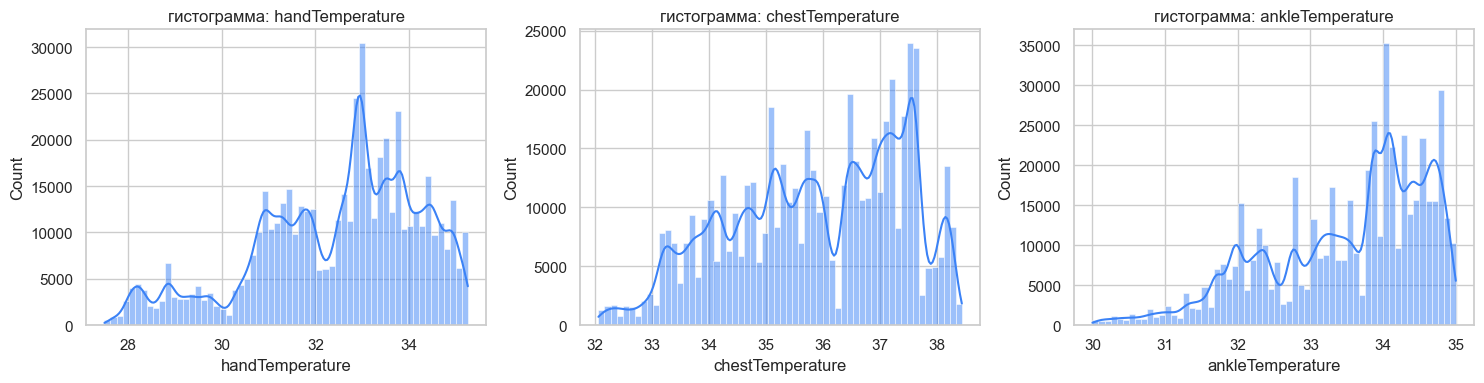

In [5]:
eda_cols = ['handTemperature', 'chestTemperature', 'ankleTemperature']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes.ravel(), eda_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color='#3b82f6')
    ax.set_title(f'гистограмма: {col}')
plt.tight_layout()
plt.show()


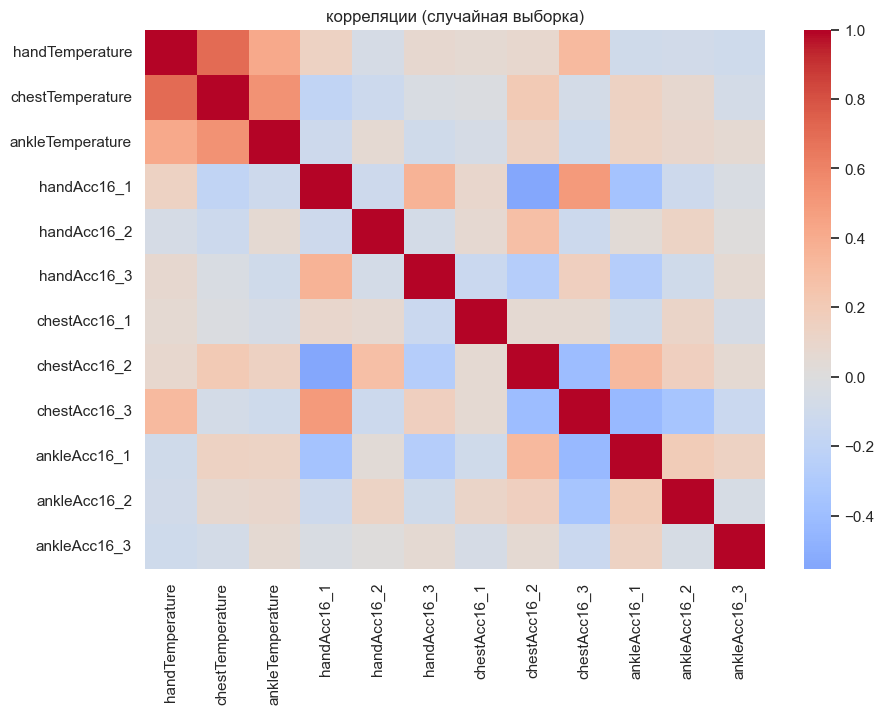

In [6]:
# корреляции только на подвыборке
sample_corr = df.sample(min(25000, len(df)), random_state=RANDOM_STATE)
corr_cols = ['handTemperature', 'chestTemperature', 'ankleTemperature',
             'handAcc16_1', 'handAcc16_2', 'handAcc16_3',
             'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3',
             'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3']

plt.figure(figsize=(10, 7))
sns.heatmap(sample_corr[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title('корреляции (случайная выборка)')
plt.show()


## 3. Предобработка

- Убрал timestamp и subject_id
- StandardScaler чтобы все признаки были в одном масштабе;
- PCA с n_components=0.95


In [7]:
drop_cols = ['timestamp', 'subject_id']
feature_cols = [c for c in df.columns if c not in drop_cols]

x = df[feature_cols].copy()

# медианой заливаю пропуски
x = x.fillna(x.median(numeric_only=True))

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
x_pca = pca.fit_transform(x_scaled)

print('сколько признаков до PCA:', x.shape[1])
print('сколько компонент после PCA:', x_pca.shape[1])
print('накопленная объясненная дисперсия:', round(pca.explained_variance_ratio_.sum(), 4))


сколько признаков до PCA: 51
сколько компонент после PCA: 32
накопленная объясненная дисперсия: 0.9548


## Алгоритм кластеризации

В условии нужно ровно 8 классов, поэтому везде  n_clusters=8 или n_components=8 для GMM


In [ ]:
k = 8

idx = np.random.choice(len(x_pca), size=min(120000, len(x_pca)), replace=False)
x_eval = x_pca[idx]

models = {
    'MiniBatchKMeans': MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=4096, n_init=20),
    'GaussianMixture': GaussianMixture(n_components=k, covariance_type='diag', random_state=RANDOM_STATE),
    'Birch': Birch(n_clusters=k, threshold=0.5)
}

rows = []
for name, model in models.items():
    labels = model.fit_predict(x_eval)
    rows.append({
        'model': name,
        'silhouette': silhouette_score(x_eval, labels),
        'davies_bouldin': davies_bouldin_score(x_eval, labels),
        'calinski_harabasz': calinski_harabasz_score(x_eval, labels)
    })

metrics_df = pd.DataFrame(rows).sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False])
display(metrics_df)


In [ ]:
# беру модель с лучшим silhouette (чем больше тем лучше)
best_name = metrics_df.iloc[0]['model']
print('по таблице метрик выиграла:', best_name)

if best_name == 'MiniBatchKMeans':
    best_model = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=4096, n_init=30)
elif best_name == 'GaussianMixture':
    best_model = GaussianMixture(n_components=k, covariance_type='diag', random_state=RANDOM_STATE)
else:
    best_model = Birch(n_clusters=k, threshold=0.5)

cluster_raw = best_model.fit_predict(x_pca)
df['cluster_raw'] = cluster_raw

print('кластеры посчитаны, сколько точек в каждом:')
display(df['cluster_raw'].value_counts().sort_index().to_frame('count'))


## Разбор кластеров и присвоение activityID

- по каждому кластеру среднюю норму ускорения корень из суммы квадратов по осям для руки, груди и лодыжки
- кластеры сортируем по activity_score

In [ ]:
def acc_norm(df_part, prefix):
    return np.sqrt(
        df_part[f'{prefix}Acc16_1']**2 +
        df_part[f'{prefix}Acc16_2']**2 +
        df_part[f'{prefix}Acc16_3']**2
    )

tmp = df.copy()
tmp['hand_acc_norm'] = acc_norm(tmp, 'hand')
tmp['chest_acc_norm'] = acc_norm(tmp, 'chest')
tmp['ankle_acc_norm'] = acc_norm(tmp, 'ankle')

profile = tmp.groupby('cluster_raw')[['hand_acc_norm', 'chest_acc_norm', 'ankle_acc_norm', 'handTemperature', 'chestTemperature', 'ankleTemperature']].mean()

# activity_score — просто взвешенная сумма z-score по фичам
z_profile = (profile - profile.mean()) / profile.std(ddof=0)
profile['activity_score'] = (
    0.35 * z_profile['hand_acc_norm'] +
    0.35 * z_profile['chest_acc_norm'] +
    0.20 * z_profile['ankle_acc_norm'] +
    0.10 * z_profile[['handTemperature', 'chestTemperature', 'ankleTemperature']].mean(axis=1)
)

profile = profile.sort_values('activity_score')
profile['activityID'] = np.arange(1, len(profile) + 1)

cluster_to_activity = profile['activityID'].to_dict()
df['activityID'] = df['cluster_raw'].map(cluster_to_activity).astype(int)

display(profile)
print('какой кластер в какой activityID ушёл:', cluster_to_activity)


In [ ]:
submission = pd.DataFrame({
    'index': np.arange(len(df)),
    'activityID': df['activityID'].astype(int)
})

submission.to_csv('submission.csv', index=False)
profile.to_csv('cluster_profile.csv')

display(submission.head())
print('для себя: cluster_profile.csv')


## Вывод

По внутренним метрикам лучше всего сработал MiniBatchKMeans: silhouette = 0.148, davies_bouldin = 2.21, calinski_harabasz = 8841.66. 

У Birch и GaussianMixture значения получились хуже, поэтому в финал взял именно k-means

После обучения кластеры распределились неравномерно: самый большой кластер — 1 (101116 объектов), самый маленький — ` (7641 объектов). Это похоже на нормальную ситуацию для реальных данных активности, где какие-то режимы движения встречаются сильно чаще других.

![](image.png)

![](image%20copy.png)